In [1]:
import numpy as np

from stack import Stack, svdStack, doubleStack
from reduction import remove_outside_neurons, remove_weak_neurons, compute_bvv, get_cluster_weights
from reduction import cluster_neurons, svd_affine

import tqdm
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Composite Sine Experiments

## Defining the Composite Sine Function

In [2]:
def function_library(function="sine", p=[0.4, 1.0, 2.0, -3.0]):

    if function == "sine":
        return lambda x: np.sin(np.pi * x[:, 0]).reshape(-1, 1)

    elif function == "scaledSine":
        # use p[1] as the scale/frequency multiplier
        return lambda x: np.sin(np.pi * p[1] * x[:, 0]).reshape(-1, 1)

    elif function == "oneKink":
        return lambda x: (
            p[2] * (x[:, 0] < p[0]) * (x[:, 0] - p[0])
            + p[1]
            + p[3] * (x[:, 0] > p[0]) * (x[:, 0] - p[0])
        ).reshape(-1, 1)

    elif function == "abs":
        return lambda x: (np.abs(x[:, 0] - 0.4) + 0.5).reshape(-1, 1)

    elif function == "squared":
        return lambda x: (x[:, 0] ** 2 - 0.5).reshape(-1, 1)

    elif function == "negToPos":
        return lambda x: (2.0 * (x[:, 0] > 0) - 1).astype(float).reshape(-1, 1)

    elif function == "cubed":
        return lambda x: (x[:, 0] ** 3).reshape(-1, 1)

    elif function == "exp":
        return lambda x: (np.exp(x[:, 0]) * 0.7357 - 1).reshape(-1, 1)

    elif function == "compositeSinePlus":
        def composite(x):
            # compute a scaled sine and apply several transforms to it
            scaled = function_library("scaledSine", p=p)(x)
            # ensure (n,1)
            if scaled.ndim == 1:
                scaled = scaled.reshape(-1, 1)

            comps = [
                function_library("oneKink", p=p)(scaled),
                function_library("abs", p=p)(scaled),
                function_library("squared", p=p)(scaled),
                function_library("negToPos", p=p)(scaled),
                function_library("cubed", p=p)(scaled),
                function_library("sine", p=p)(scaled),
                function_library("exp", p=p)(scaled),
                # keep one original-oneKink applied to the raw x as a distinct column
                function_library("oneKink", p=p)(x),
            ]
            return np.hstack(comps)

        return composite


def generate_data(n_samples=1000, function="sine", p=[0.4, 1.0, 2.0, -3.0], interval=(-1, 1)):
    x = np.random.uniform(interval[0], interval[1], (n_samples, 1))
    y = function_library(function, p)(x)
    # ensure y is at least 2D column or already multi-output
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    return x, y


def generate_noisy_data(n_samples=1000, function="sine", p=[0.4, 1.0, 2.0, -3.0], interval=(-1, 1), noise_std=0.1):
    x = np.random.uniform(interval[0], interval[1], (n_samples, 1))
    y = function_library(function, p)(x)
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    # add noise matching y's shape (supports multi-output)
    y = y + np.random.normal(0, noise_std, y.shape)
    return x, y


def plot_data(x, y, function="sine"):
    import matplotlib.pyplot as plt
    plt.scatter(x, y, alpha=0.5)
    plt.title(f"{function} function")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid()
    plt.show()

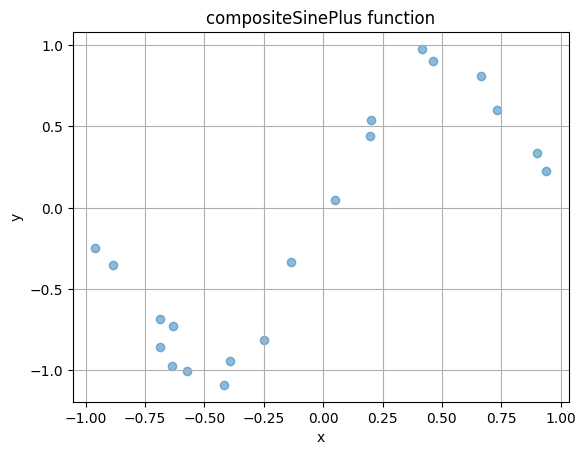

In [3]:
# fix random seed for reproducibility
np.random.seed(42)

# x, y = generate_noisy_data(n_samples=1000, function="compositeSinePlus", p=[0.4, 1.0, 2.0, -3.0], interval=(-1, 1), noise_std=0.1)
x, y = generate_noisy_data(n_samples=20, function="sine", p=[0.4, 1.0, 2.0, -3.0], interval=(-1, 1), noise_std=0.1)
# x.shape, y.shape
plot_data(x, y, function="compositeSinePlus")

## Evaluate trained model on Composite Sine Data

In [33]:
# model should be a double stack with 1 neuron linear bottleneck layer

# weight_decay=0.001, function == "compositeSinePlus", lr=1e-3
# model = doubleStack(neurons_per_layer=[1, 1024, 1, 1024, 8])
# checkpoint = torch.load("lightning_logs/version_2/checkpoints/epoch=199-step=200.ckpt")['state_dict']
# checkpoint = torch.load("lightning_logs/version_3/checkpoints/epoch=1999-step=2000.ckpt")['state_dict']

# weight_decay=0.001, function == "compositeSinePlus", lr=1e-4
# checkpoint = torch.load("lightning_logs/version_5/checkpoints/epoch=1999-step=2000.ckpt")['state_dict']

# weight_decay=0.0001, function == "compositeSinePlus", lr=1e-4
# checkpoint = torch.load("lightning_logs/version_6/checkpoints/epoch=1999-step=2000.ckpt")['state_dict']

# weight_decay=0.001, function == "compositeSine", lr=1e-3
model = doubleStack(neurons_per_layer=[1, 1024, 1, 1024, 7])
checkpoint = torch.load("lightning_logs/version_4/checkpoints/epoch=1999-step=2000.ckpt")['state_dict']

for k in list(checkpoint.keys()):
    checkpoint[k.removeprefix('model.')] = checkpoint.pop(k)
model.load_state_dict(checkpoint)

<All keys matched successfully>

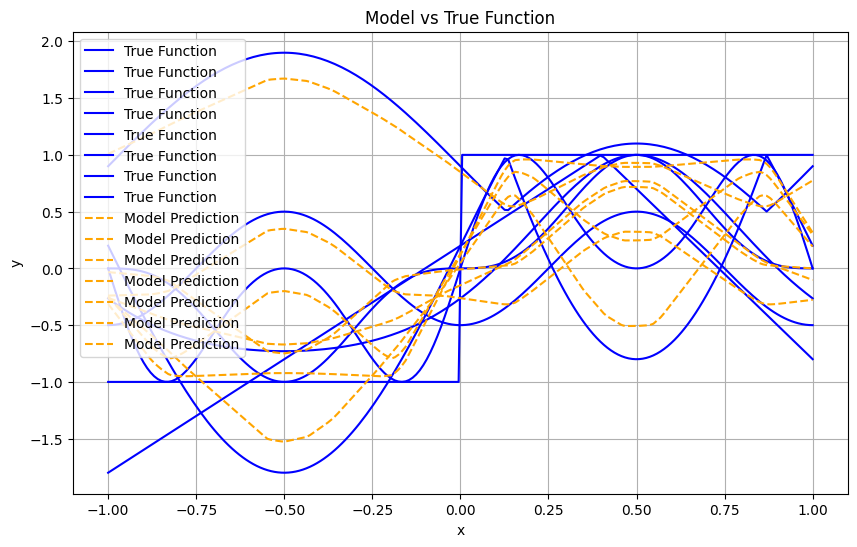

In [34]:
# visualize the original function and the model's predictions
import matplotlib.pyplot as plt
x_test = np.linspace(-1, 1, 200).reshape(-1, 1)
y_true = function_library("compositeSinePlus", p=[0.4, 1.0, 2.0, -3.0])(x_test)
model.eval()
with torch.no_grad():
    y_pred = model(torch.tensor(x_test, dtype=torch.float32))

# with torch.no_grad():
#     y_pred = model.stack1(torch.tensor(x_test, dtype=torch.float32))
#     y_pred = model.stack2(y_pred)

plt.figure(figsize=(10, 6))
plt.plot(x_test, y_true, label="True Function", color="blue")
plt.plot(x_test, y_pred.numpy(), label="Model Prediction", color="orange", linestyle="--")
plt.title("Model vs True Function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

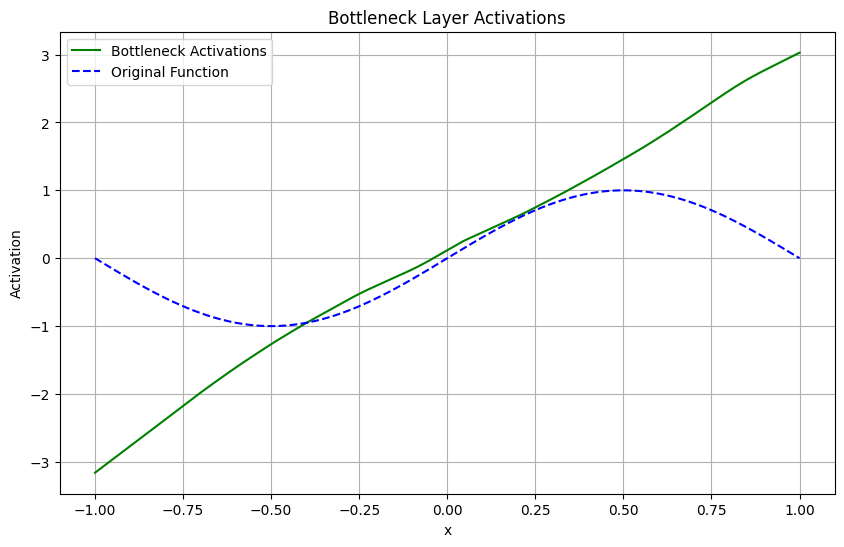

In [30]:
# let's visualize the intermediate representations in the bottleneck layer to see if it has learned a meaningful transformation and compare it to the original function
def get_bottleneck_activations(model, x):
    # we need to run the input through the first stack, then through the bottleneck layer, and capture the activations
    with torch.no_grad():
        x_tensor = torch.tensor(x, dtype=torch.float32)
        # pass through first stack
        bottleneck_activations = model.stack1(x_tensor)
    return bottleneck_activations.numpy()

bottleneck_acts = get_bottleneck_activations(model, x_test)

plt.figure(figsize=(10, 6))
plt.plot(x_test, bottleneck_acts, label="Bottleneck Activations", color="green")
plt.plot(x_test, function_library("scaledSine")(x_test), label="Original Function", color="blue", linestyle="--")
plt.title("Bottleneck Layer Activations")
plt.xlabel("x")
plt.ylabel("Activation")
plt.legend()
plt.grid()
plt.show()

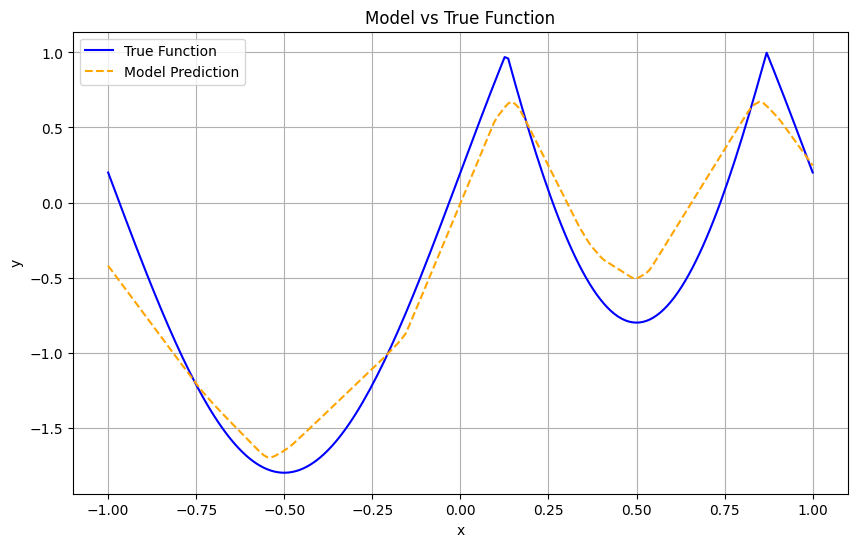

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x_test, y_true[:, 0], label="True Function", color="blue")
plt.plot(x_test, y_pred[:, 0].numpy(), label="Model Prediction", color="orange", linestyle="--")
plt.title("Model vs True Function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

# End